# Calibration (host noise-floor): CS-01 TAS

**Purpose**: characterise the per-host noise floor that every `experiment` run depends on. Four probes (timer resolution, scheduling jitter, loopback latency, empty-handler scaling) produce one JSON envelope that `05-experimental.ipynb` and `06-yoly-experimental.ipynb` reference when reporting measured latencies.

**Inputs**: none. Host identity (hostname, OS, CPU count, RAM) is snapshotted at runtime.

**Outputs**:
- `data/results/experiment/calibration/<host>_<YYYYMMDD_HHMMSS>.json`: the full calibration envelope.
- `data/img/experiment/calibration/dashboard.{png,svg}`: 2x2 summary card (timer / jitter / loopback / handler scaling).
- `data/img/experiment/calibration/scaling.{png,svg}`: standalone empty-handler scaling line plot.

**Equivalent CLI**:
```bash
python src/methods/calibration.py
```

**How to use the baseline**: every measured experiment latency on this host should be reported as:

```
reported = measured_us - loopback.median_us  +/- jitter.p99_us
```

i.e. subtract the loopback median (host overhead), report the jitter p99 as the uncertainty band. Any measured value below `loopback.median_us` is an instrument error, not a real service. Full plan + checkpoint log in [notes/calibration.md](notes/calibration.md).

This notebook is thin: all logic lives in `src.methods.calibration` (runner) and `src.view.characterization` (plotters). The cells below just call `run()` and display.

In [1]:
%matplotlib inline
from pathlib import Path
import json

import pandas as pd

from src.io import (
    # load_dim_card,
    # load_latest_calibration,
    load_method_cfg,
)
from src.methods.calibration import derive_calib_coefs, run, run_calib_sweep
from src.view import (
    plot_calib_dashboard,
    plot_calib_rate_sweep,
    plot_calib_scaling,
    # plot_arts_distributions,
    # plot_yoly_arts_behaviour,
    # plot_yoly_arts_charts,
    plot_yoly_chart,
)

IMG_ROOT = Path("data/img/experiment/calibration")

# Toggle the rate-saturation probe. Default False so a rerun stays under ~3 min;
# flip to True to also run the experiment-method at the configured rate ladder
# x trials_per_rate (adds ~10-15 min wall time depending on the ladder).
RUN_RATE_SWEEP = True

# Per-request body size (bytes) for the phi coefficient in the dim card.
# Sourced from data/config/method/calibration.json::payload_size_bytes
# (e.g. 131072 = 128 kB). 0 keeps phi NaN (degenerate-memory case).
PAYLOAD_BYTES = int(load_method_cfg("calibration").get("payload_size_bytes", 0))


## 1. Run the four probes

`run()` executes under `winmm.timeBeginPeriod(1)` on Windows (no-op elsewhere). Default sample counts take ~60-90 s on a 16-core laptop; tune via keyword args if needed (e.g. `jitter_samples=500, loopback_samples=500, per_worker=20, n_con_usr=(1, 10)` for a ~8 s smoke).

The envelope is written to `data/results/experiment/calibration/<host>_<timestamp>.json` and returned in-memory for the display cells below.

In [2]:
envelope = run(write=True, verbose=True,
               skip_rate_sweep=not RUN_RATE_SWEEP)
print(f"\nwrote: {envelope.get('output_path')}")


  [1/4] timer resolution ...
  [2/4] scheduling jitter ...
  [3/4] loopback latency ...
  [4/4] vernier handler scaling ...
      c=     1  running 500 requests ...
      c=     1  done in 1.8s  median=3360.7us  p99=5864.8us
      c=    10  running 500 requests ...
      c=    10  done in 2.2s  median=21083.3us  p99=171840.5us
      c=    50  running 500 requests ...
      c=    50  done in 2.7s  median=119785.1us  p99=1117330.2us
      c=   100  running 500 requests ...
      c=   100  done in 2.8s  median=307072.2us  p99=1984158.7us
      c=   200  running 400 requests ...
      c=   200  done in 2.1s  median=589983.1us  p99=1883321.0us
      c=   300  running 300 requests ...
      c=   300  done in 1.3s  median=572991.3us  p99=1179388.2us
      c=   500  running 500 requests ...
      c=   500  done in 2.3s  median=1099497.5us  p99=2076225.6us
      c=  1000  running 1000 requests ...
      c=  1000  done in 4.4s  median=1561372.5us  p99=4068242.6us

  [5/5] rate saturation sweep .

## 2. Host profile

The machine the rest of the calibration was measured against. Record thermals / background load conditions in [notes/devlog.md](notes/devlog.md) when benching formally.

In [3]:
host = envelope["host_profile"]
pd.Series({
    "hostname": host.get("hostname"),
    "os": host.get("os"),
    "python": f"{host.get('python')} ({host.get('python_impl')})",
    "cpu_count": host.get("cpu_count"),
    "cpu_machine": host.get("cpu_machine"),
    "ram_total_gb": round(float(host.get("ram_total_gb") or 0), 2),
    "timestamp": envelope.get("timestamp"),
    "elapsed_s": envelope.get("elapsed_s"),
}, name="value")

hostname                  DESKTOP-INKGBK6
os              Windows-11-10.0.26200-SP0
python                  3.12.10 (CPython)
cpu_count                              16
cpu_machine                         AMD64
ram_total_gb                        63.75
timestamp             2026-04-26T18:36:42
elapsed_s                         155.968
Name: value, dtype: object

## 3. Probe summary tables

Each probe reports a distribution summary. Acronyms expanded below:

- **min**: minimum observed value; for `timer` this is the actual clock resolution.
- **median / p50**: 50th percentile (half the samples are faster, half slower).
- **mean**: arithmetic mean.
- **p95 / p99**: 95th / 99th percentile (worst-case tail behaviour).
- **max**: single worst sample.
- **std**: standard deviation (dispersion).
- **ns**: nanoseconds (10^-9 s).  **us**: microseconds (10^-6 s).

In [4]:
timer = envelope.get("timer", {})
jitter = envelope.get("jitter", {})
loopback = envelope.get("loopback", {})

pd.DataFrame({
    "timer [ns]": {
        "min": timer.get("min_ns"),
        "median / p50": timer.get("median_ns"),
        "mean": timer.get("mean_ns"),
        "std": timer.get("std_ns"),
    },
    "jitter [us]": {
        "mean": jitter.get("mean_us"),
        "median / p50": jitter.get("p50_us"),
        "p99": jitter.get("p99_us"),
        "max": jitter.get("max_us"),
    },
    "loopback [us]": {
        "min": loopback.get("min_us"),
        "median / p50": loopback.get("median_us"),
        "p95": loopback.get("p95_us"),
        "p99": loopback.get("p99_us"),
    },
}).round(2)

,timer [ns],jitter [us],loopback [us]
min,100.00,NaN,1988.10
median / p50,100.00,589.50,2801.45
mean,132.46,598.88,NaN
std,156.76,NaN,NaN
p99,NaN,1214.98,5800.81
max,NaN,3047.20,NaN
p95,NaN,NaN,4168.13


## 4. Handler scaling table

Empty `/ping` endpoint, keep-alive, measured at increasing in-flight request counts. Growing gap between `c=1` and `c=10` indicates how much the FastAPI event loop queues when concurrent requests stack up; often the real driver of prototype latency rise at high rates.

In [5]:
handler = envelope.get("handler_scaling", {})
rows = []
for c, stats in sorted(handler.items(), key=lambda p: int(p[0])):
    rows.append({
        "n_con_usr": int(c),
        "min [us]": stats.get("min_us"),
        "median / p50 [us]": stats.get("median_us"),
        "p95 [us]": stats.get("p95_us"),
        "p99 [us]": stats.get("p99_us"),
        "samples": stats.get("samples"),
    })
pd.DataFrame(rows).set_index("n_con_usr").round(1)

,min [us],median / p50 [us],p95 [us],p99 [us],samples
n_con_usr,,,,,
1,2756.0,3360.6,5050.4,5864.8,500
10,3967.1,21083.4,31171.5,171840.5,500
50,4297.5,119785.2,664988.7,1117330.2,500
100,4468.6,307072.2,1360265.1,1984158.7,500
200,15820.6,589983.0,1710737.1,1883321.0,400
300,328128.3,572991.3,1075423.9,1179388.2,300
500,531721.2,1099497.5,1956858.1,2076225.6,500
1000,1065361.4,1561372.5,3833030.7,4068242.6,500


## 5. Calibration dashboard (single-figure summary)

2x2 card combining the three headline bar charts with the handler-scaling line plot. The suptitle carries the host identity, timestamp, and the `reported = measured - loopback_median +/- jitter_p99` formula so the figure is usable on its own as a dissertation appendix.

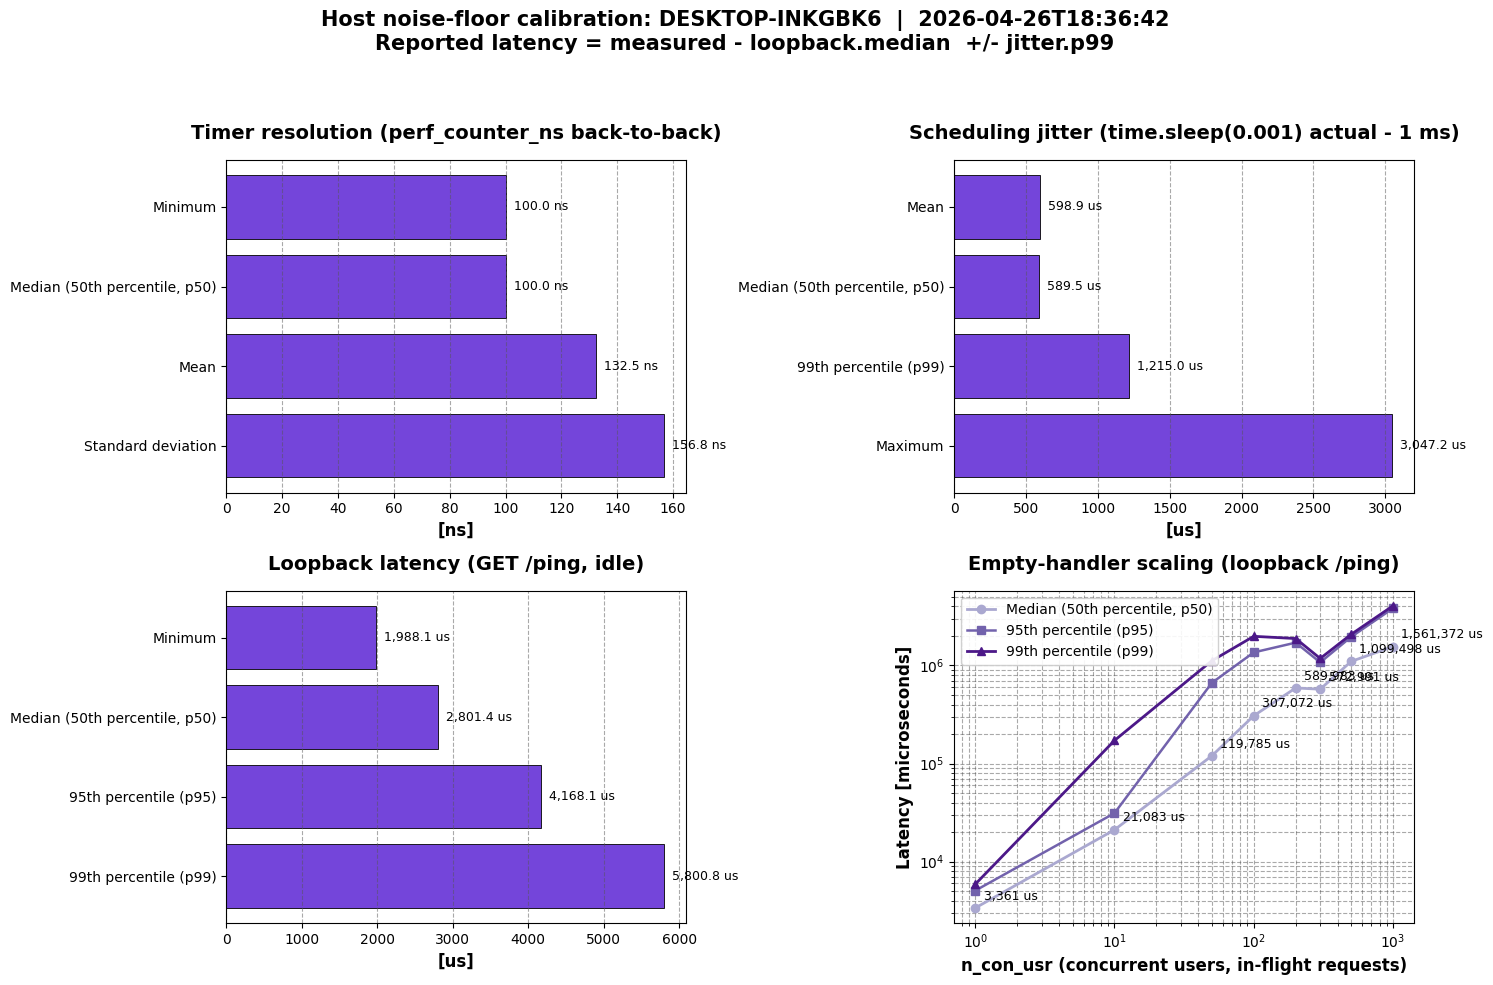

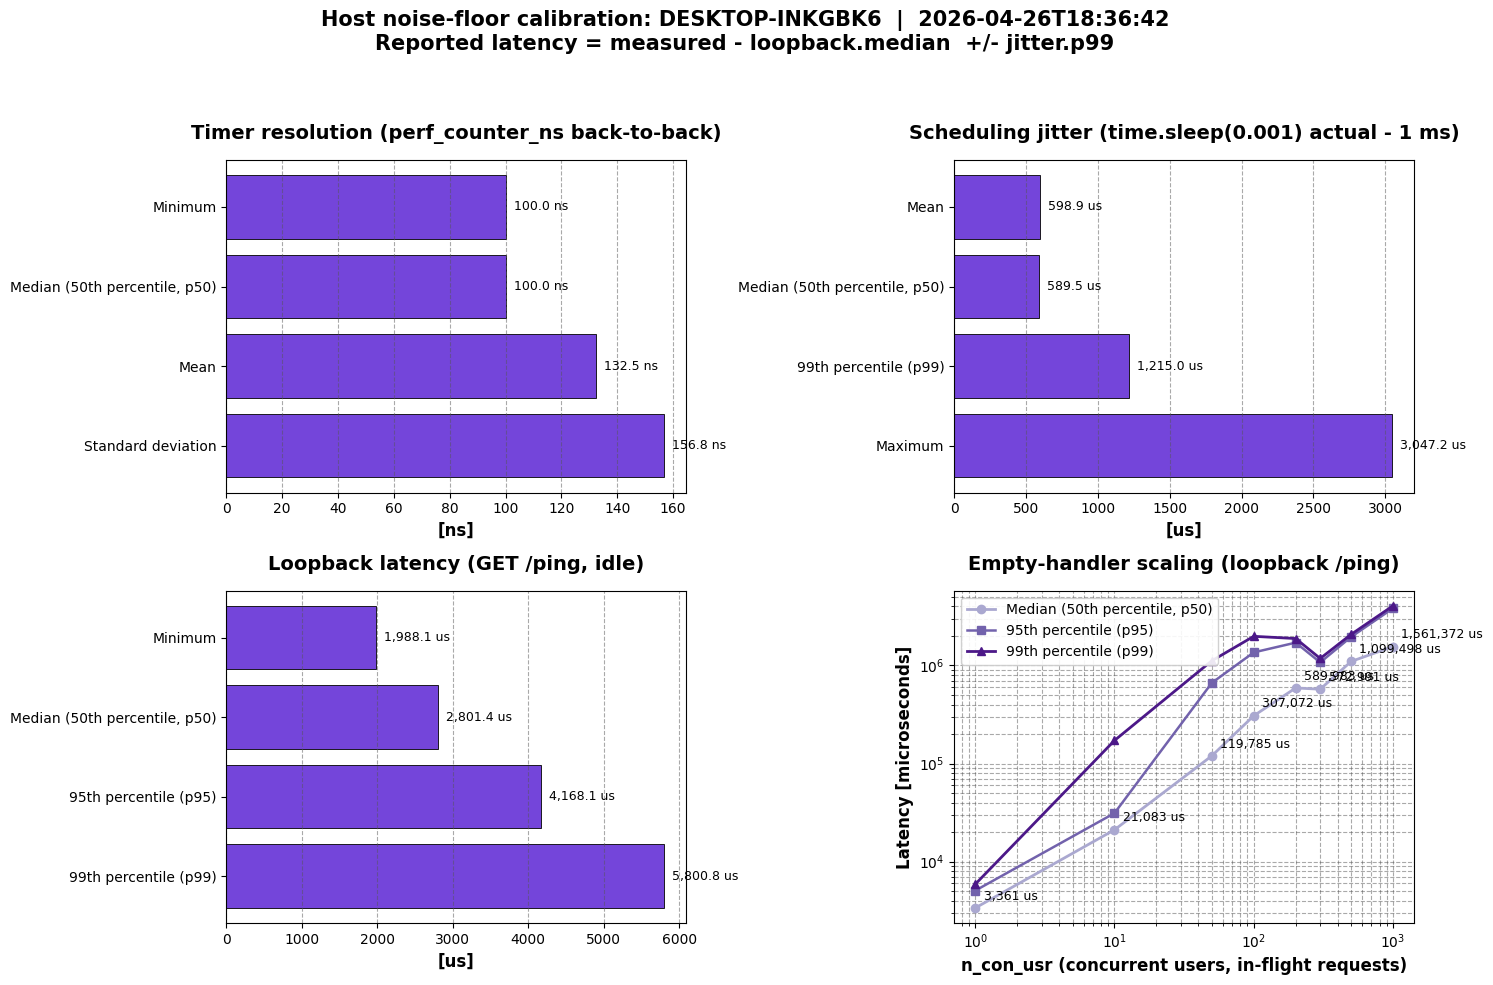

In [6]:
plot_calib_dashboard(
    envelope,
    file_path=str(IMG_ROOT),
    fname="dashboard.png",
)

## 6. Handler-scaling detail

Standalone line plot: median (p50), 95th percentile (p95), 99th percentile (p99) vs `n_con_usr` (concurrent users, in-flight requests) on the CLIENT side. The SERVICE stays at `c_srv=1` (single uvicorn worker) throughout. Log-log axes so the span from `n_con_usr=1` to `n_con_usr=10000` is legible.

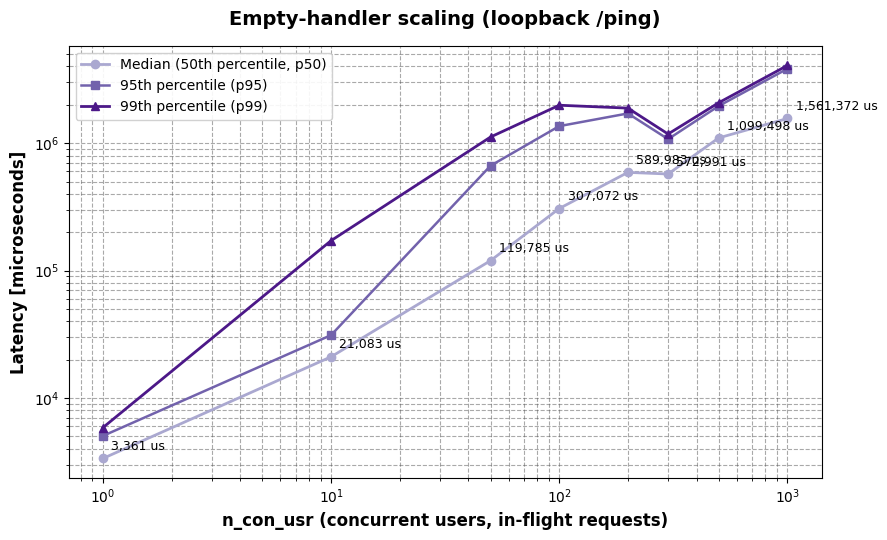

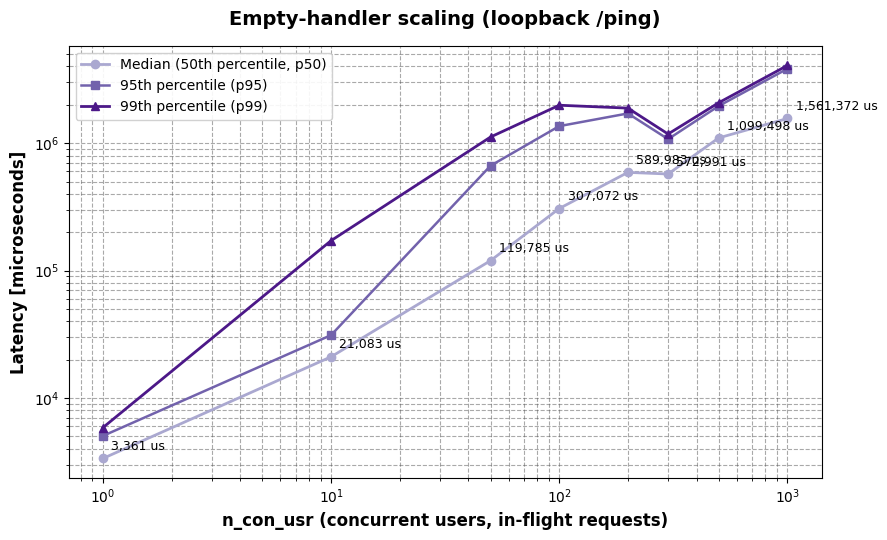

In [7]:
plot_calib_scaling(
    envelope.get("handler_scaling", {}),
    file_path=str(IMG_ROOT),
    fname="scaling.png",
)

## 6b. Dimensional coefficient card (Route B: measured)

Host-specific dimensionless signature of the single-worker (`c_srv=1`) calibration `/ping` service. Coefficients are derived directly from the measured `handler_scaling` and `loopback` blocks (Route B — measurement, not M/M/c/K prediction) using `src.methods.calibration.derive_calib_coefs`. `mu` comes from the idle loopback probe (`mu = 1e6 / loopback.median_us`); the handler-scaling curve supplies `R`, `X`, `L`, `Wq` at each `n_con_usr` level.

- **theta = L / K**: queue occupancy.
- **sigma = W * lambda / K**: Stall; queueing share of capacity.
- **eta = X * K / (mu * c_srv)**: effective-yield vs host service-rate ceiling.
- **phi = (L * payload) / (K * payload) = L / K**: memory-usage; degenerate here because every `/ping` request carries the same payload (so `phi == theta`). Populated with `NaN` when `payload_size_bytes=0`; becomes informative only with the payload-echo upgrade.
- **epsilon** is structurally 0 (the service has no business logic that can fail) and is therefore NOT part of this card.

The 2x2 figure rendered below reuses `src.view.dc_charts.plot_yoly_chart` — the same plotter the TAS dimensional method uses on actual architecture coefficients. Saved as `dim_card.{png,svg}`.

pipeline       : pydasa.MonteCarloSimulation(mode=DATA)
payload_size_B : 128000
mu_req_per_s   : 356.96
n_con_usr      : [1, 10, 50, 100, 200, 300, 500, 1000]


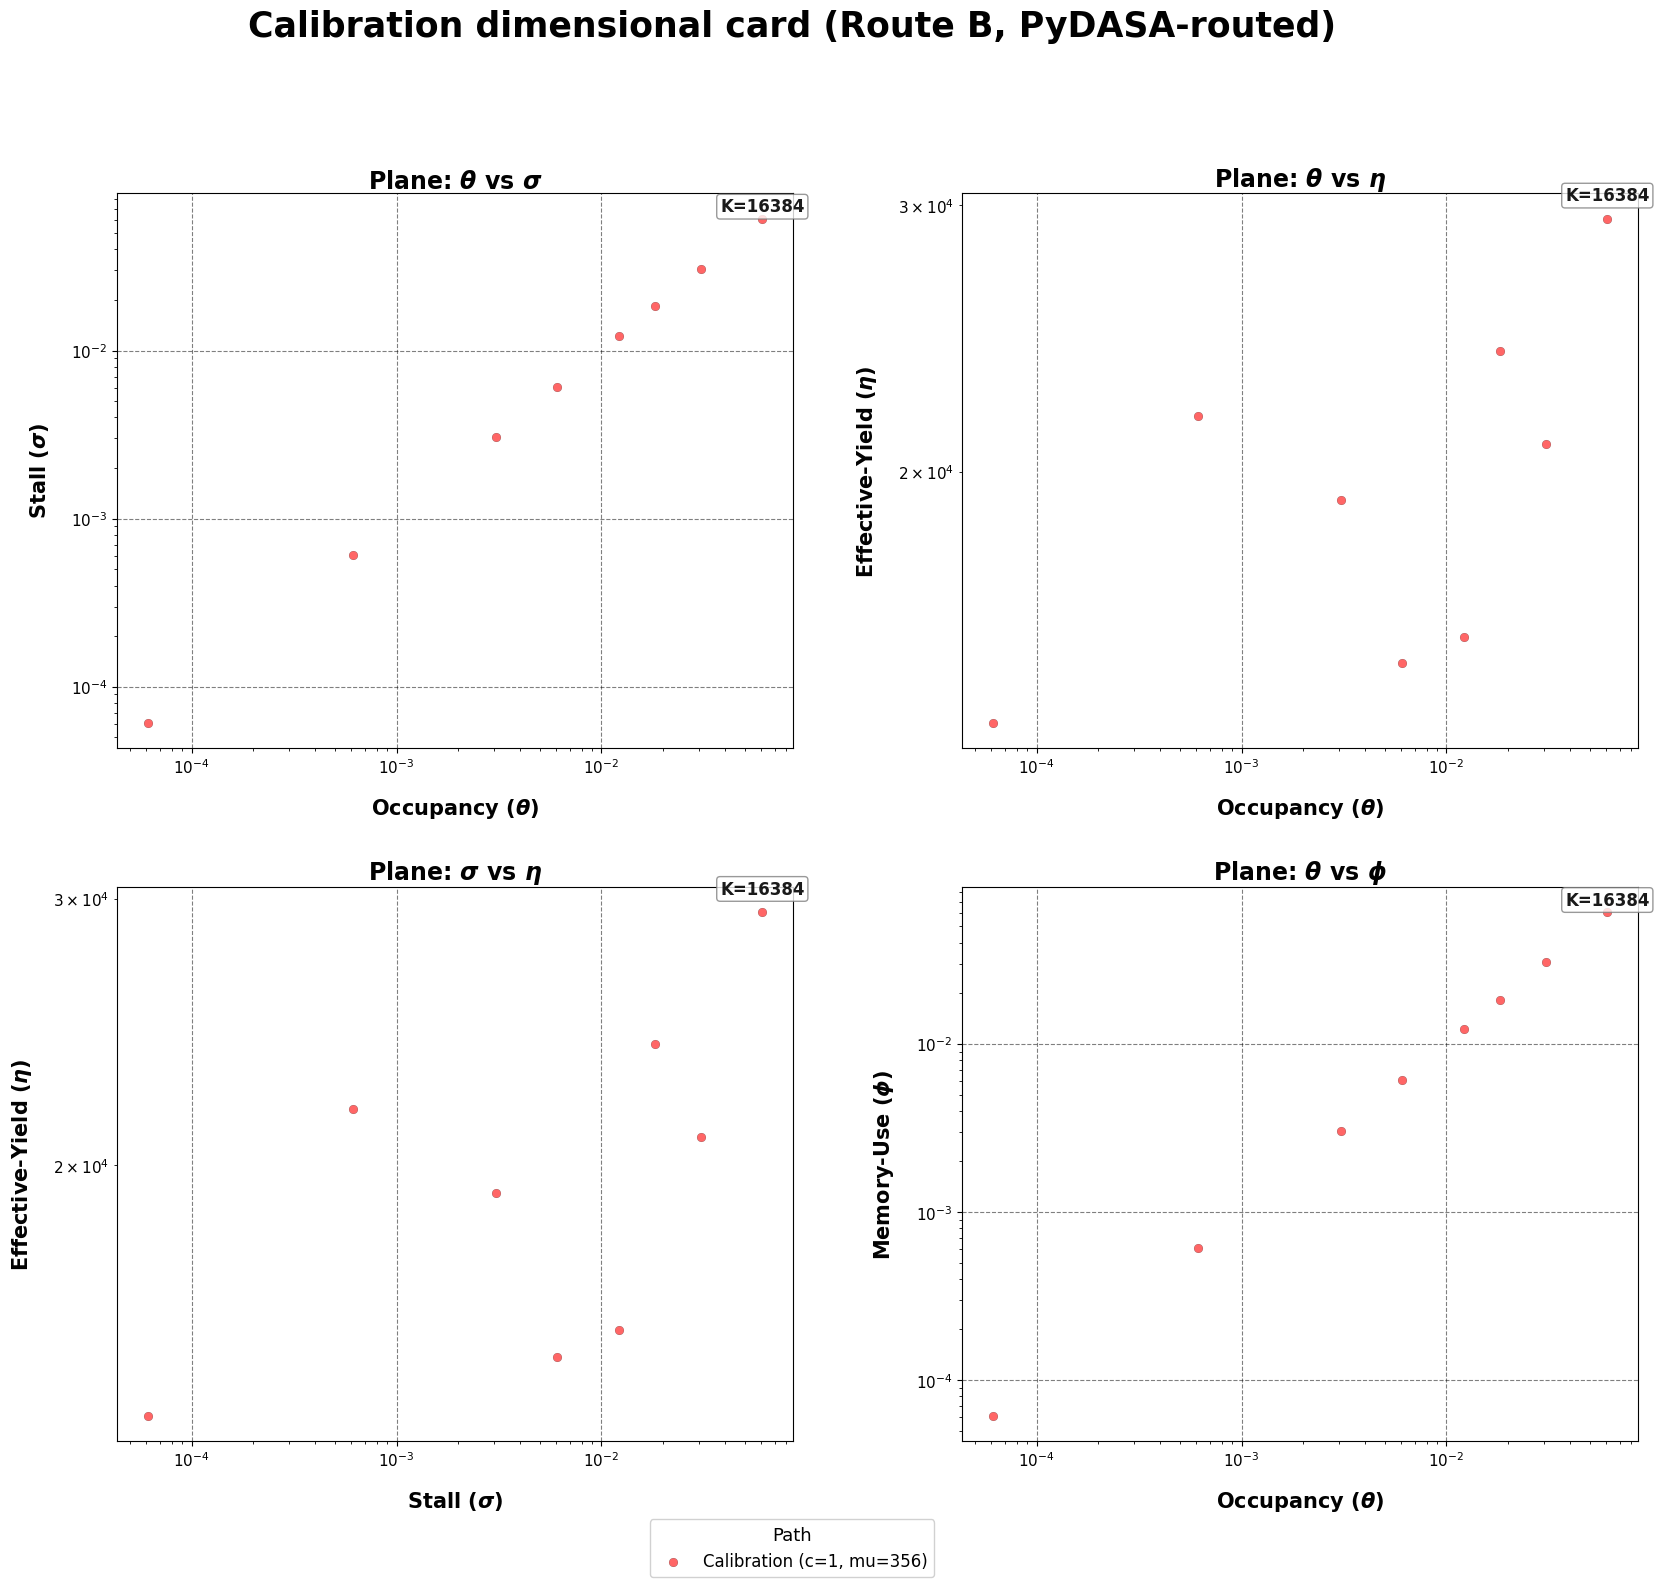

In [8]:
dim_card = envelope.get("dimensional_card")
if not dim_card:
    dim_card = derive_calib_coefs(envelope, payload_size_bytes=PAYLOAD_BYTES)

if not dim_card:
    print("dimensional_card unavailable -- loopback or handler_scaling missing.")
else:
    meta = dim_card.get("meta", {})
    print(f"pipeline       : {meta.get('pipeline')}")
    print(f"payload_size_B : {meta.get('payload_size_bytes')}")
    print(f"mu_req_per_s   : {meta.get('mu_req_per_s'):.2f}")
    print(f"n_con_usr      : {meta.get('n_con_usr')}")

    logscale = bool(PAYLOAD_BYTES)  # phi is NaN when payload=0 -> linear scale
    plot_yoly_chart(
        dim_card,
        paths={"Calibration": "CALIB"},
        logscale=logscale,
        title="Calibration dimensional card (Route B, PyDASA-routed)",
        file_path=str(IMG_ROOT),
        fname="dim_card.png",
        verbose=False,
    )


## 7. Rate saturation (optional)

Only populated when `_RUN_RATE_SWEEP = True` in the setup cell. Drives the full experiment mesh at the configured rate ladder (default `[100, 200, 300, 400, 500]` req/s x 5 trials) and reports the highest rate the mesh sustains under the configured loss target. Figure saved as `rate_sweep.{png,svg}` alongside the dashboard.


,effective mean,effective range,mean loss [%],entry lambda mean,trials
target [req/s],,,,,
10.0,10.451,"[10.43, 10.47]",-4.508,10.451,11
50.0,50.090,"[49.93, 50.20]",-0.179,50.090,11
100.0,100.465,"[99.74, 100.97]",-0.465,100.465,11
200.0,200.560,"[194.20, 202.03]",-0.280,200.560,11
280.0,282.688,"[278.92, 286.08]",-0.960,282.688,11
300.0,297.610,"[281.87, 304.13]",0.797,297.610,11
320.0,299.459,"[267.86, 323.50]",6.419,299.459,11



Highest sustainable rate at <= 2.0% mean loss: 300.0 req/s


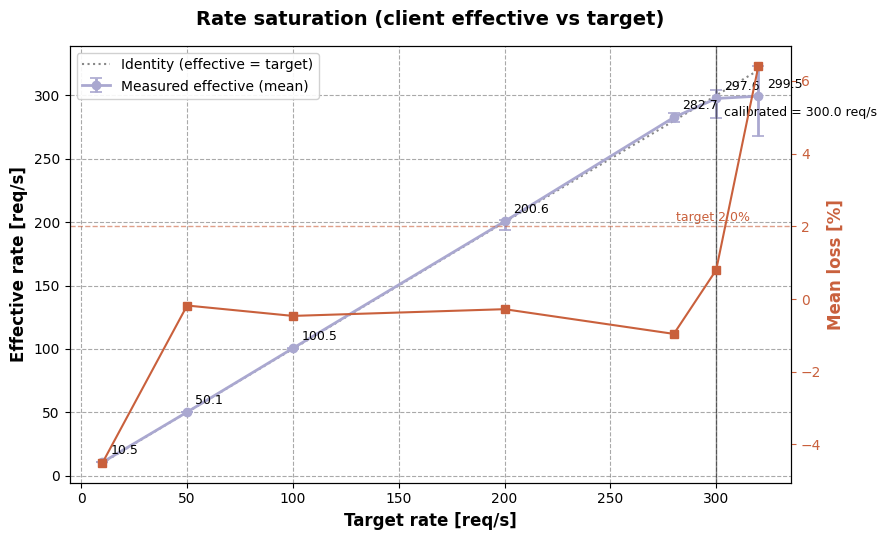

In [9]:
rate_sweep = envelope.get("rate_sweep")
if rate_sweep is None:
    print("rate_sweep block absent -- set RUN_RATE_SWEEP = True and re-run "
          "the probe cell to populate it.")
else:
    rows = []
    for k in sorted(rate_sweep["aggregates"].keys(), key=lambda x: float(x)):
        a = rate_sweep["aggregates"][k]
        rows.append({
            "target [req/s]": float(k),
            "effective mean": a.get("mean"),
            "effective range": f'[{a.get("lo", 0):.2f}, {a.get("hi", 0):.2f}]',
            "mean loss [%]": a.get("mean_loss_pct"),
            "entry lambda mean": a.get("mean_entry_lambda"),
            "trials": a.get("n"),
        })
    display(pd.DataFrame(rows).set_index("target [req/s]").round(3))
    cal = rate_sweep.get("calibrated_rate")
    target = rate_sweep.get("target_loss_pct")
    if cal is None:
        print(f"\nNo rate cleared the {target}% mean-loss bar.")
    else:
        print(f"\nHighest sustainable rate at <= {target}% mean loss: "
              f"{float(cal):.1f} req/s")

    plot_calib_rate_sweep(
        rate_sweep,
        file_path=str(IMG_ROOT),
        fname="rate_sweep.png",
    )


## 7b. Measured sweep across (c, K, mu_factor) (Route B: vernier-driven)

Drives the vernier echo service across the `sweep_grid` cartesian (`mu_factor x c x K`) using `run_calib_sweep`. Each combo spins up a fresh vernier with the combo's spec, ramps `lambda` from `lambda_factor_min*mu` up to `util_threshold*mu*c` across `lambda_steps` points, drives each step at the target rate, and feeds the per-step latency stats through `derive_calib_coefs` to produce one dim card per combo. No queue theory, just real measurements.

**Off by default.** Set `_RUN_CALIB_SWEEP = True` in the setup cell (or here) to opt in. Default grid (`mu_factor=[0.5,1,1.5,2]` x `c=[1,2,4]` x `K=[50,100,200,500]`) yields 48 combos; total wall time scales with `lambda_steps * max_probe_window_s` per combo plus `inter_trial_delay_s` between combos.

Anchor for `mu_combo = mu_factor * mu_anchor` resolves through `sweep_grid.mu_anchor_req_per_s` (explicit, host-independent) -> `sweep_grid.mu_anchor_source` (named derivation, defaults to `loopback.median_us`). Provenance lands on every per-combo `meta` block.

In [10]:
RUN_CALIB_SWEEP = True

if RUN_CALIB_SWEEP:
    sweep = run_calib_sweep(envelope, write=True, verbose=True)
    print()
    print(f"combos: {len(sweep)}")
    if not sweep:
        print("sweep returned empty -- check loopback or sweep_grid in calibration.json")
else:
    sweep = {}
    print("sweep skipped (set RUN_CALIB_SWEEP = True to opt in; "
          "~8 min for the default 48-combo grid)")

  [1/36] CALIBc2K100m50 mu=62.5 req/s ...
  [2/36] CALIBc2K100m100 mu=125.0 req/s ...
  [3/36] CALIBc2K100m150 mu=187.5 req/s ...
  [4/36] CALIBc2K100m200 mu=250.0 req/s ...
  [5/36] CALIBc2K200m50 mu=62.5 req/s ...
  [6/36] CALIBc2K200m100 mu=125.0 req/s ...
  [7/36] CALIBc2K200m150 mu=187.5 req/s ...
  [8/36] CALIBc2K200m200 mu=250.0 req/s ...
  [9/36] CALIBc2K400m50 mu=62.5 req/s ...
  [10/36] CALIBc2K400m100 mu=125.0 req/s ...
  [11/36] CALIBc2K400m150 mu=187.5 req/s ...
  [12/36] CALIBc2K400m200 mu=250.0 req/s ...
  [13/36] CALIBc4K100m50 mu=62.5 req/s ...
  [14/36] CALIBc4K100m100 mu=125.0 req/s ...
  [15/36] CALIBc4K100m150 mu=187.5 req/s ...
  [16/36] CALIBc4K100m200 mu=250.0 req/s ...
  [17/36] CALIBc4K200m50 mu=62.5 req/s ...
  [18/36] CALIBc4K200m100 mu=125.0 req/s ...
  [19/36] CALIBc4K200m150 mu=187.5 req/s ...
  [20/36] CALIBc4K200m200 mu=250.0 req/s ...
  [21/36] CALIBc4K400m50 mu=62.5 req/s ...
  [22/36] CALIBc4K400m100 mu=125.0 req/s ...
  [23/36] CALIBc4K400m150 mu=18

In [11]:
# fallback loader: when `RUN_CALIB_SWEEP=False` AND `sweep` has no data
# in memory (fresh kernel or skipped cell 19), load the most recent
# <host>_<ts>_sweep.json from disk so the plot cell below can render
# without re-running the multi-minute sweep.
sweep = globals().get("sweep") or {}

if not sweep:
    sweep_dir = Path("data/results/experiment/calibration")
    host_stem = (envelope.get("host_profile", {})
                          .get("hostname", "")
                          .replace(" ", "-"))
    candidates = sorted(sweep_dir.glob(f"{host_stem}_*_sweep.json"))
    if candidates:
        latest = candidates[-1]
        sweep = json.loads(latest.read_text(encoding="utf-8"))["combos"]
        print(f"loaded {len(sweep)} combos from {latest.name}")
    else:
        print(f"no sweep file matching {host_stem}_*_sweep.json under {sweep_dir}")
else:
    print(f"sweep already populated ({len(sweep)} combos); skipping disk load")


sweep already populated (36 combos); skipping disk load


c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-CS1-TAS\src\view\dc_charts.py:488: UserWarning: You passed a edgecolor/edgecolors ('#010101') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(_x[_mask], _y[_mask],
c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-CS1-TAS\src\view\dc_charts.py:488: UserWarning: You passed a edgecolor/edgecolors ('#010101') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(_x[_mask], _y[_mask],
c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-CS1-TAS\src\view\dc_charts.py:488: UserWarning: You passed a edgecolor/edgecolors ('#010101') for an unfilled marker ('|').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(_x[_mask], _y[_mask],
c:\Users\Felipe\OneDri

Saving plot to: data\img\experiment\calibration\calib_sweep.png
Saving plot to: data\img\experiment\calibration\calib_sweep.svg
Plot saved successfully (calib_sweep.png + calib_sweep.svg)


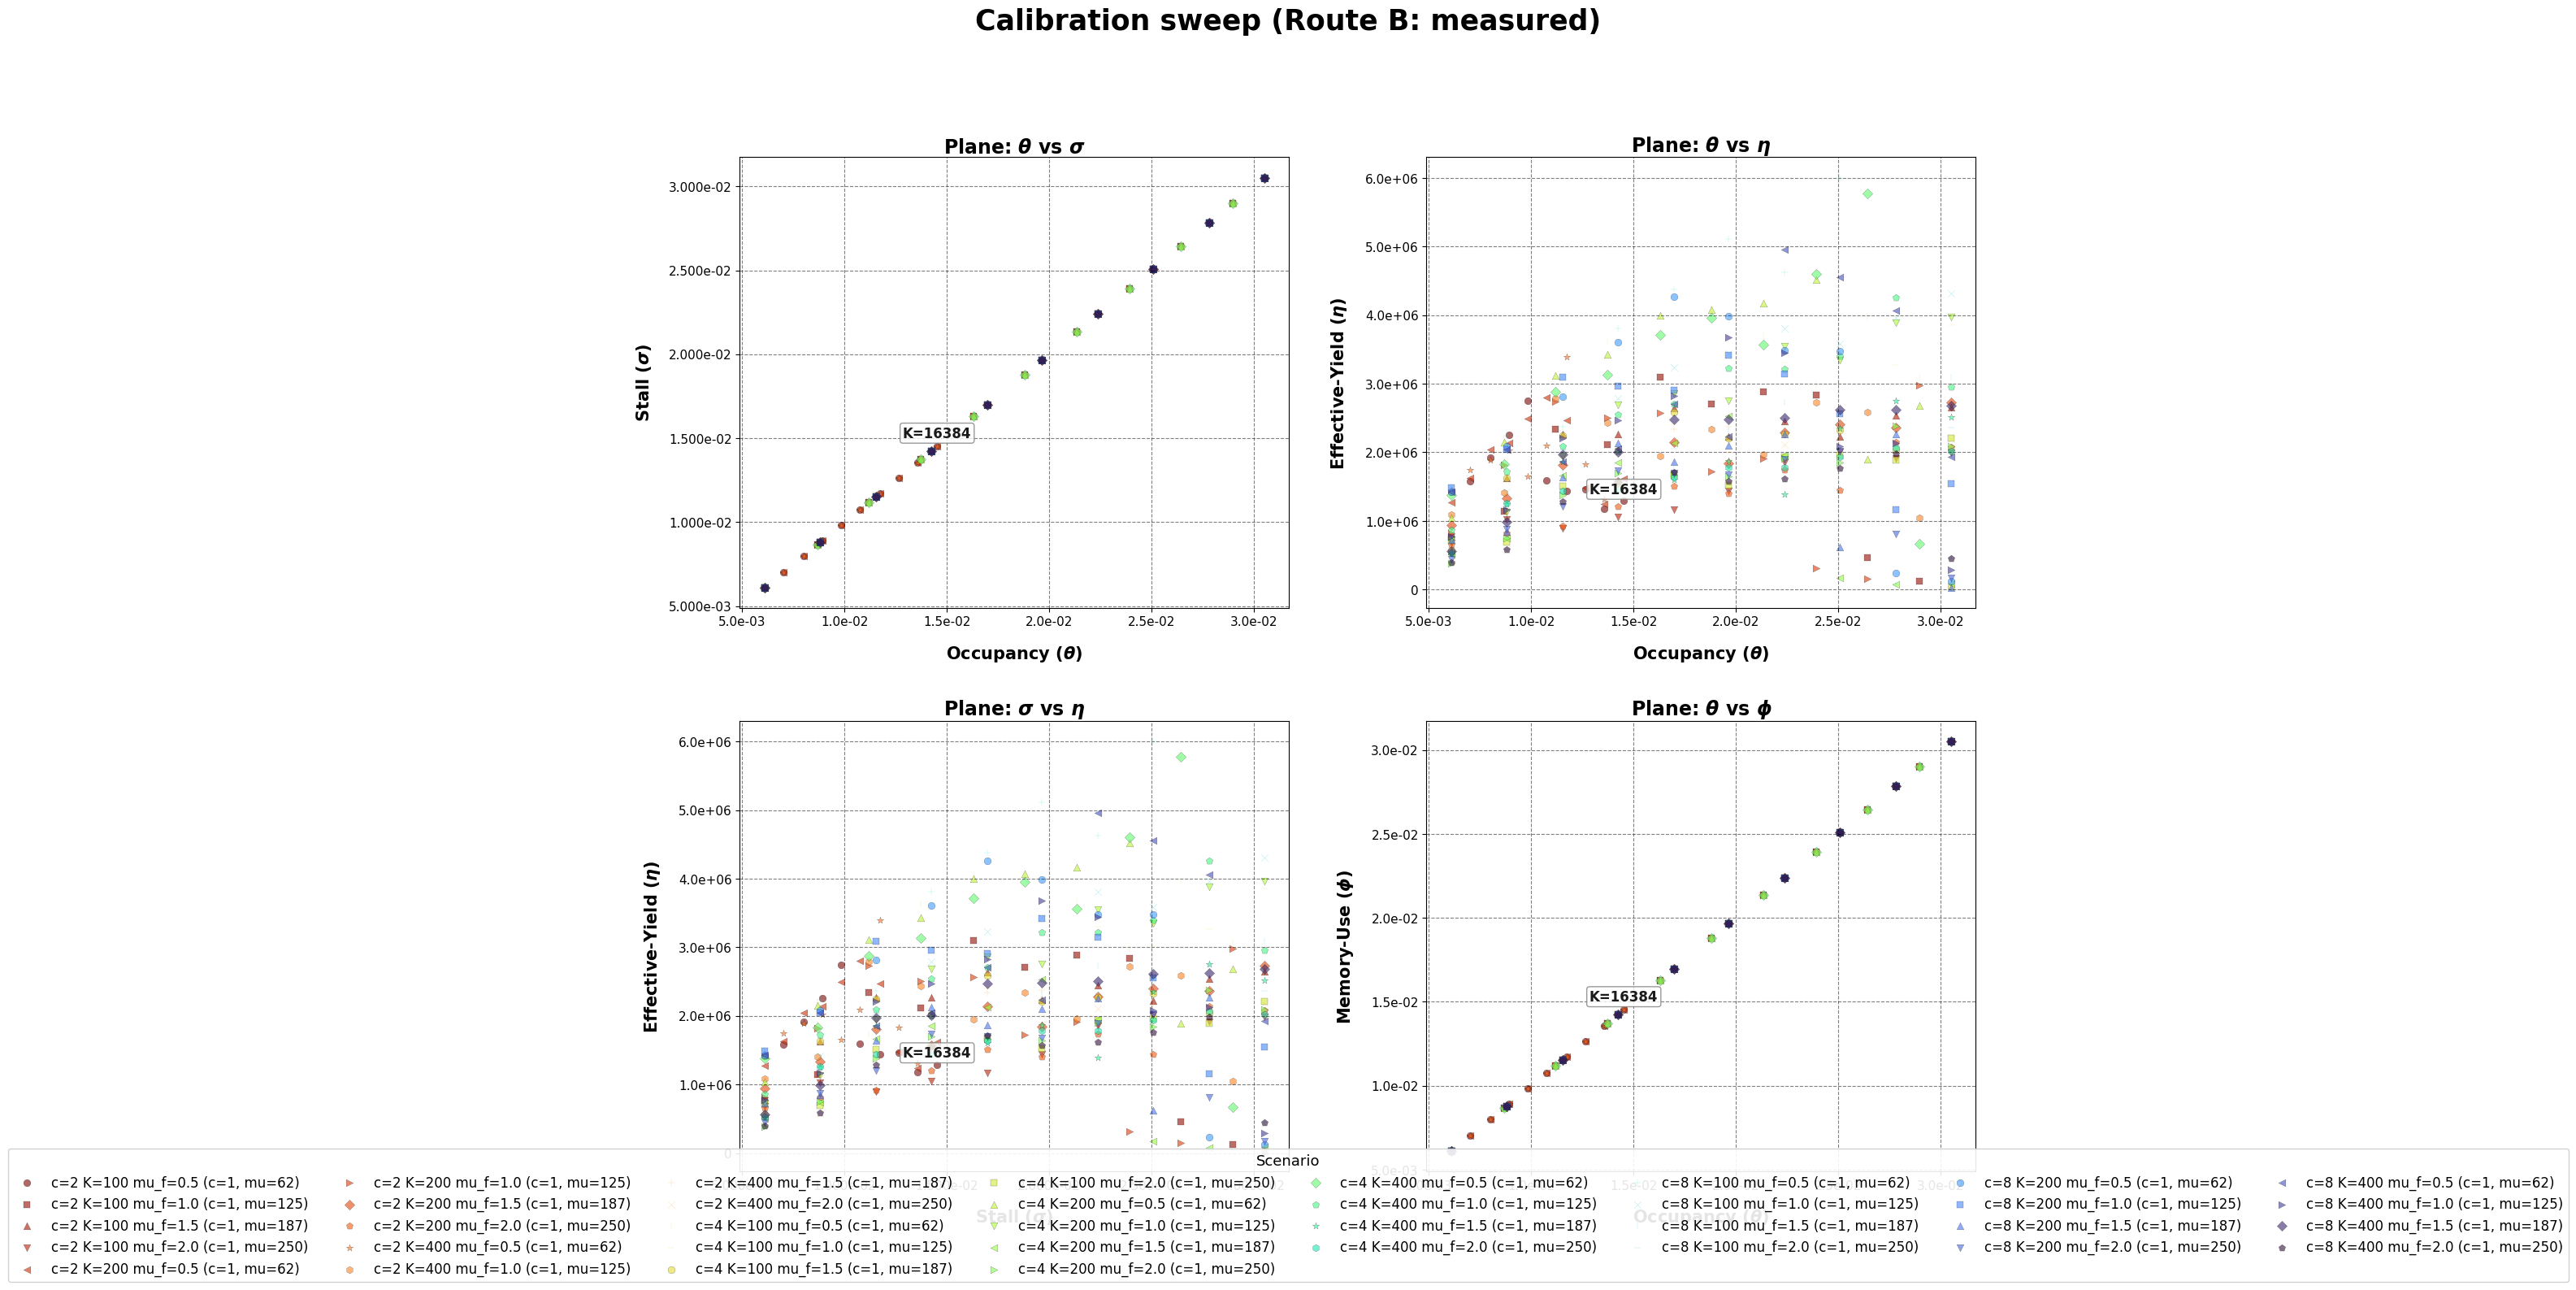

In [12]:
# render the cloud from the in-memory `sweep`; rerun this cell after
# tweaking the plot config without re-running the multi-minute sweep above
if sweep:
    # flatten nested {combo_tag: {symbol: array}} into one coeff_data dict
    overlay = {}
    for tag, block in sweep.items():
        for key, val in block.items():
            if key == "meta":
                continue
            overlay[key] = val
    # plot_yoly_chart wants {display_label: combo_tag}; the tag must be the dict VALUE so the plotter looks up the latex-keyed coefficient arrays
    scenarios = {}
    for tag, block in sweep.items():
        meta = block.get("meta", {})
        label = (f"c={meta.get('c_srv')} K={meta.get('K_capacity')} "
                  f"mu_f={meta.get('mu_factor')}")
        scenarios[label] = tag
    plot_yoly_chart(overlay,
                    scenarios=scenarios,
                    title="Calibration sweep (Route B: measured)",
                    file_path=str(IMG_ROOT),
                    fname="calib_sweep",
                    verbose=True)
else:
    print("no sweep in memory -- run the cell above with RUN_CALIB_SWEEP = True")


## 8. Apply the baseline to experiment results

The two numbers that matter when reporting later experiments on this host:


In [13]:
floor = float(loopback.get("median_us", 0.0))
band = float(jitter.get("p99_us", 0.0))
print(f"Loopback median (host overhead) : {floor:,.1f} us")
print(f"Jitter p99 (uncertainty band)   : {band:,.1f} us")
print()

print("Example: a measured experiment latency of 8300 us reports as:")
print(f"  {8300 - floor:,.1f} us  +/- {band:,.1f} us")
print()

print("Any measured latency below the host overhead is an instrument error.")

Loopback median (host overhead) : 2,801.4 us
Jitter p99 (uncertainty band)   : 1,215.0 us

Example: a measured experiment latency of 8300 us reports as:
  5,498.6 us  +/- 1,215.0 us

Any measured latency below the host overhead is an instrument error.


## Summary

Run this notebook before every fresh `05-experimental.ipynb` / `06-yoly-experimental.ipynb` session so the downstream cells can load the latest calibration JSON by timestamp. A stale baseline is fine for iteration; a dissertation-quality run pairs every experiment result with a same-session calibration.

**Next in the pipeline**: `05-experimental.ipynb` (fixed-point per-adaptation execution) and `06-yoly-experimental.ipynb` (configuration-sweep yoly).